# Computer Vision Masterclass - Recognition of gestures and actions


## Detecting body points


### Importing the libraries


In [1]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

### Loading the image


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
image = cv2.imread('/content/drive/MyDrive/Computer-Vision/Images/megan.jpg')

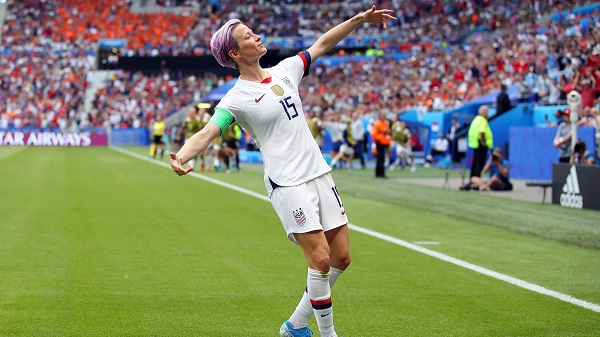

In [4]:
cv2_imshow(image)

In [5]:
image.shape, image.shape[0] * image.shape[1] * 3

((337, 600, 3), 606600)

In [6]:
type(image)

numpy.ndarray

In [7]:
# Mean subtraction: https://www.pyimagesearch.com/2017/11/06/deep-learning-opencvs-blobfromimage-works/
image_blob = cv2.dnn.blobFromImage(image=image, scalefactor=1.0 / 255,
                                   size=(image.shape[1], image.shape[0]))

In [8]:
type(image_blob), image_blob.shape  # batch

(numpy.ndarray, (1, 3, 337, 600))

### Loading the pre-trained neural network

- Caffe Deep Learning framework: https://caffe.berkeleyvision.org/


In [9]:
network = cv2.dnn.readNetFromCaffe('/content/drive/MyDrive/Computer-Vision/Weights/pose_deploy_linevec_faster_4_stages.prototxt',
                                   '/content/drive/MyDrive/Computer-Vision/Weights/pose_iter_160000.caffemodel')

In [10]:
network.getLayerNames()

('conv1_1',
 'relu1_1',
 'conv1_2',
 'relu1_2',
 'pool1_stage1',
 'conv2_1',
 'relu2_1',
 'conv2_2',
 'relu2_2',
 'pool2_stage1',
 'conv3_1',
 'relu3_1',
 'conv3_2',
 'relu3_2',
 'conv3_3',
 'relu3_3',
 'conv3_4',
 'relu3_4',
 'pool3_stage1',
 'conv4_1',
 'relu4_1',
 'conv4_2',
 'relu4_2',
 'conv4_3_CPM',
 'relu4_3_CPM',
 'conv4_4_CPM',
 'relu4_4_CPM',
 'conv5_1_CPM_L1',
 'relu5_1_CPM_L1',
 'conv5_1_CPM_L2',
 'relu5_1_CPM_L2',
 'conv5_2_CPM_L1',
 'relu5_2_CPM_L1',
 'conv5_2_CPM_L2',
 'relu5_2_CPM_L2',
 'conv5_3_CPM_L1',
 'relu5_3_CPM_L1',
 'conv5_3_CPM_L2',
 'relu5_3_CPM_L2',
 'conv5_4_CPM_L1',
 'relu5_4_CPM_L1',
 'conv5_4_CPM_L2',
 'relu5_4_CPM_L2',
 'conv5_5_CPM_L1',
 'conv5_5_CPM_L2',
 'concat_stage2',
 'Mconv1_stage2_L1',
 'Mrelu1_stage2_L1',
 'Mconv1_stage2_L2',
 'Mrelu1_stage2_L2',
 'Mconv2_stage2_L1',
 'Mrelu2_stage2_L1',
 'Mconv2_stage2_L2',
 'Mrelu2_stage2_L2',
 'Mconv3_stage2_L1',
 'Mrelu3_stage2_L1',
 'Mconv3_stage2_L2',
 'Mrelu3_stage2_L2',
 'Mconv4_stage2_L1',
 'Mrelu4_sta

In [11]:
len(network.getLayerNames())

127

### Predicting body points


In [12]:
network.setInput(image_blob)
output = network.forward()

In [13]:
# 44 -> related to the points that were detected
# (43, 75) -> information about the location
output.shape

(1, 44, 43, 75)

In [14]:
position_width = output.shape[3]
position_heigth = output.shape[2]

In [15]:
position_width

75

In [16]:
(image.shape[1] * 28) / 75

224.0

In [17]:
# minMaxLoc: https://docs.opencv.org/master/d2/de8/group__core__array.html#gab473bf2eb6d14ff97e89b355dac20707
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
    # print(i)
    confidence_map = output[0, i, :, :]
    # print(confidence_map) # candidate points
    # print(len(confidence_map))
    _, confidence, _, point = cv2.minMaxLoc(confidence_map)
    # print(confidence)
    # print(point)

    x = int((image.shape[1] * point[0]) / position_width)
    y = int((image.shape[0] * point[1]) / position_heigth)
    # print(x,y)
    if confidence > threshold:
        cv2.circle(image, (x, y), 5, (0, 255, 0), thickness=-1)
        cv2.putText(image, '{}'.format(i), (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255))
        points.append((x, y))
    else:
        points.append(None)

In [18]:
points

[(224, 23),
 (248, 62),
 (232, 94),
 (208, 125),
 (176, 148),
 (280, 62),
 (320, 39),
 (360, 15),
 (288, 180),
 (320, 250),
 (320, 321),
 (312, 164),
 (336, 250),
 (296, 305),
 (280, 125)]

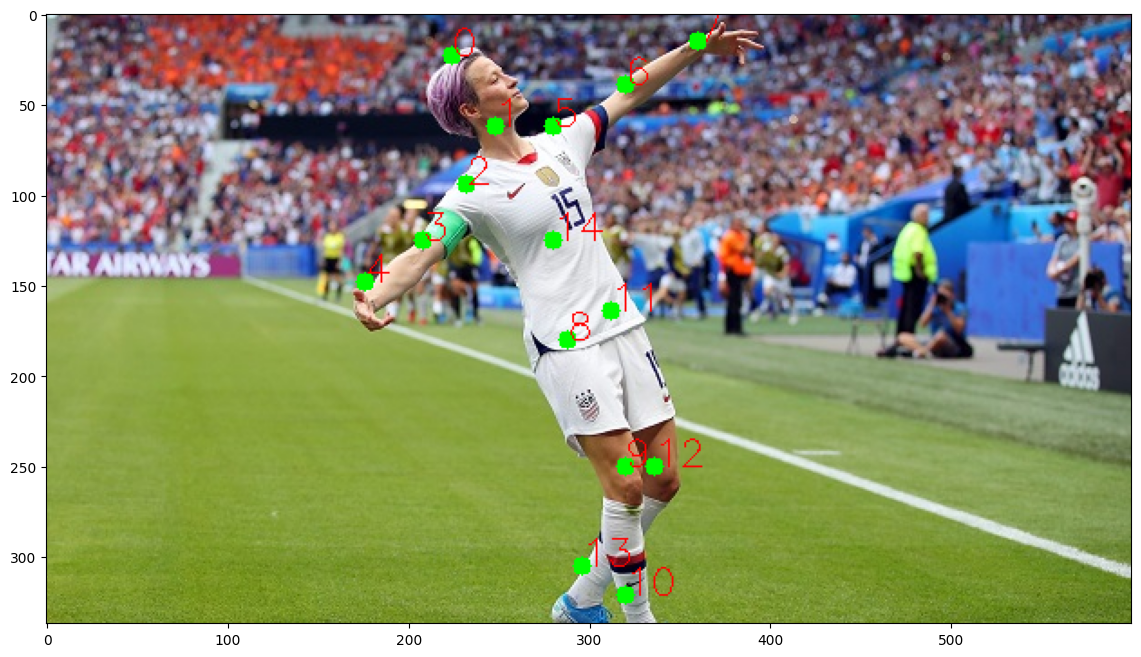

In [19]:
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [20]:
point_connections = [[0, 1], [1, 2], [2, 3], [3, 4], [1, 5], [5, 6], [6, 7], [1, 14],
                     [14, 8], [8, 9], [9, 10], [14, 11], [11, 12], [12, 13]]

In [21]:
point_connections

[[0, 1],
 [1, 2],
 [2, 3],
 [3, 4],
 [1, 5],
 [5, 6],
 [6, 7],
 [1, 14],
 [14, 8],
 [8, 9],
 [9, 10],
 [14, 11],
 [11, 12],
 [12, 13]]

In [22]:
for connection in point_connections:
    # print(connection)
    partA = connection[0]
    partB = connection[1]
    # print(partA, partB)
    if points[partA] and points[partB]:
        cv2.line(image, points[partA], points[partB], (255, 0, 0))

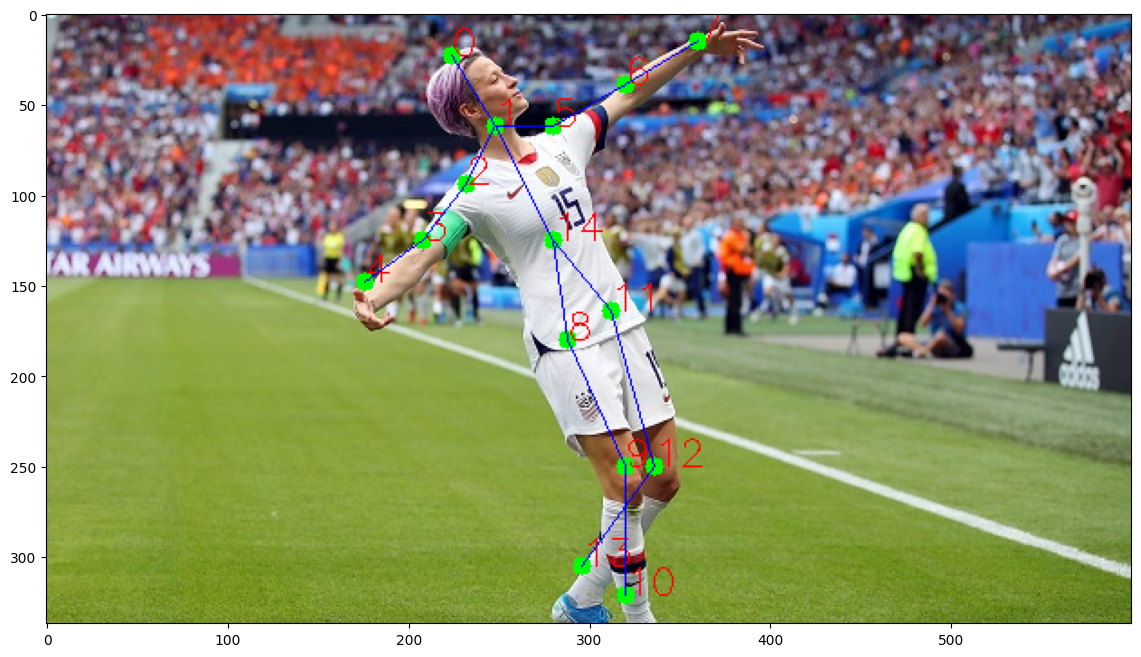

In [23]:
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Detecting movements (arms above the head)


### Arms above the head in images


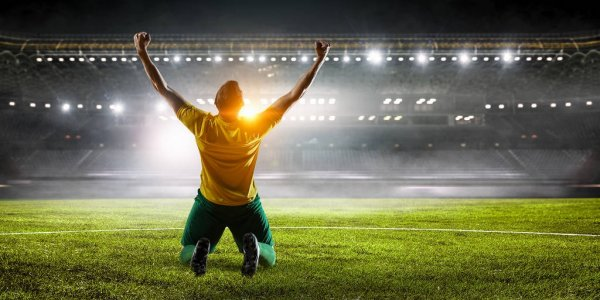

In [24]:
image2 = cv2.imread('/content/drive/MyDrive/Computer-Vision/Images/player.jpg')
cv2_imshow(image2)

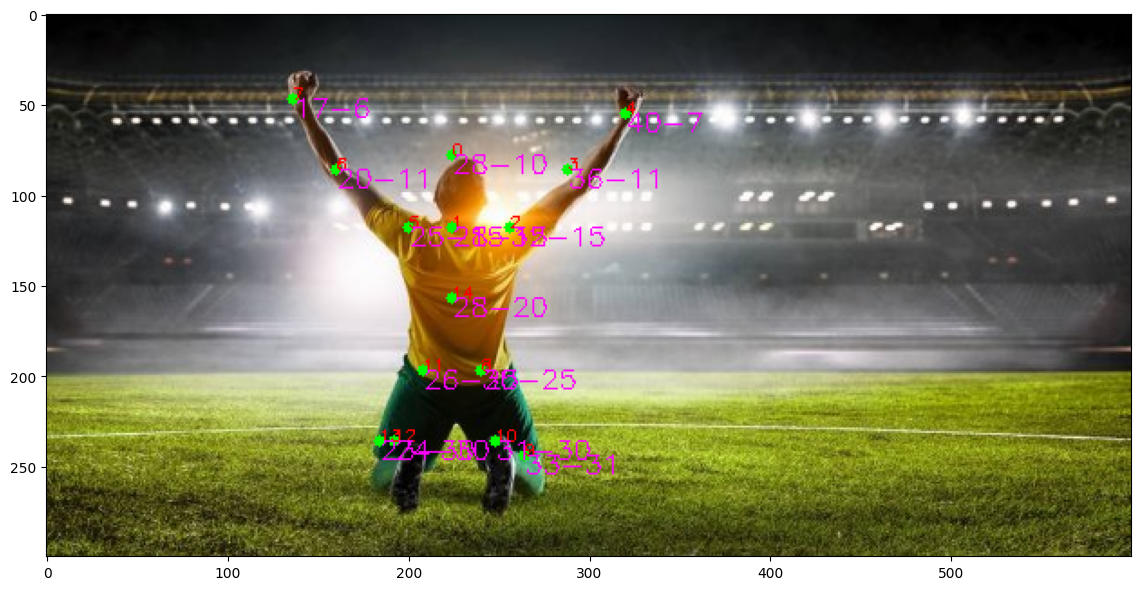

In [25]:
image2 = cv2.imread('/content/drive/MyDrive/Computer-Vision/Images/player.jpg')
image_blob2 = cv2.dnn.blobFromImage(
    image=image2, scalefactor=1.0 / 255, size=(image2.shape[1], image2.shape[0]))
network.setInput(image_blob2)
output2 = network.forward()
position_width = output2.shape[3]
position_height = output2.shape[2]
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
    confidence_map = output2[0, i, :, :]
    _, confidence, _, point = cv2.minMaxLoc(confidence_map)
    x = int((image2.shape[1] * point[0]) / position_width)
    y = int((image2.shape[0] * point[1]) / position_height)

    if confidence > threshold:
        cv2.circle(image2, (x, y), 3, (0, 255, 0), thickness=-1)
        cv2.putText(image2, "{}".format(i), (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, .3, (0, 0, 255))
        cv2.putText(image2, '{}-{}'.format(point[0], point[1]),
                    (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, .5, (255, 0, 255))
        points.append((x, y))
    else:
        points.append(None)

plt.figure(figsize=[14, 10])
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))

In [26]:
def verify_arms_up(points):
    head, right_wrist, left_wrist = 0, 0, 0
    for i, point in enumerate(points):
        # print(i, point)
        if i == 0:
            head = point[1]
        elif i == 4:
            right_wrist = point[1]
        elif i == 7:
            left_wrist = point[1]

    # print(head, right_wrist, left_wrist)
    if right_wrist < head and left_wrist < head:
        return True
    else:
        return False

In [27]:
verify_arms_up(points)

True

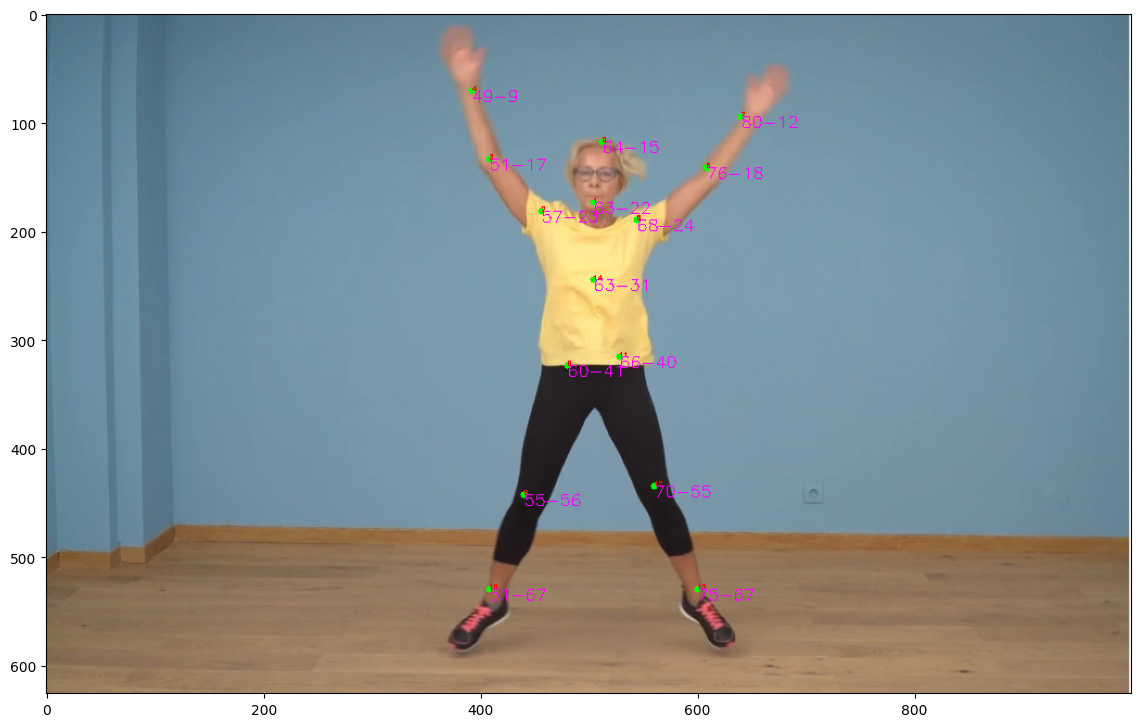

In [28]:
image = cv2.imread('/content/drive/MyDrive/Computer-Vision/Images/jump.jpg')
image_blob = cv2.dnn.blobFromImage(
    image=image, scalefactor=1.0 / 255, size=(image.shape[1], image.shape[0]))
network.setInput(image_blob)
output = network.forward()
position_width = output.shape[3]
position_height = output.shape[2]
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
    confidence_map = output[0, i, :, :]
    _, confidence, _, point = cv2.minMaxLoc(confidence_map)
    x = int((image.shape[1] * point[0]) / position_width)
    y = int((image.shape[0] * point[1]) / position_height)

    if confidence > threshold:
        cv2.circle(image, (x, y), 3, (0, 255, 0), thickness=-1)
        cv2.putText(image, "{}".format(i), (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, .2, (0, 0, 255))
        cv2.putText(image, "{}-{}".format(point[0], point[1]),
                    (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, .5, (255, 0, 255))
        points.append((x, y))
    else:
        points.append(None)

plt.figure(figsize=[14, 10])
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [29]:
def verify_legs_apart(points):
    left_hip, rigth_hip = 0, 0
    left_ankle, right_ankle = 0, 0

    for i, point in enumerate(points):
        if i == 11:
            left_hip = point[0]
        elif i == 8:
            rigth_hip = point[0]
        elif i == 13:
            left_ankle = point[0]
        elif i == 10:
            rigth_ankle = point[0]

    if (left_ankle > left_hip) and (rigth_ankle < rigth_hip):
        return True
    else:
        return False

In [30]:
verify_legs_apart(points)

True

### Arms above the head in videos

- VideoWriter_fourcc: https://www.programcreek.com/python/example/89348/cv2.VideoWriter_fourcc


In [31]:
video = '/content/drive/MyDrive/Computer-Vision/Videos/gesture1.mp4'
capture = cv2.VideoCapture(video)
connected, frame = capture.read()

In [32]:
connected

True

In [33]:
frame.shape

(1080, 808, 3)

In [34]:
result = '/content/drive/MyDrive/Computer-Vision/Videos/gesture1_result.mp4'
save_video = cv2.VideoWriter(result, cv2.VideoWriter_fourcc(
    *'XVID'),  10, (frame.shape[1], frame.shape[0]))

In [ ]:
# https://stackoverflow.com/questions/5217519/what-does-opencvs-cvwaitkey-function-do
threshold = 0.1

while True:
    connected, frame = capture.read()
    if not connected:
        break

    image_blob = cv2.dnn.blobFromImage(
        image=frame, scalefactor=1.0 / 255, size=(256, 256))
    network.setInput(image_blob)
    output = network.forward()

    position_height = output.shape[2]
    position_width = output.shape[3]

    num_points = 15
    points = []
    for i in range(num_points):
        confidence_map = output[0, i, :, :]
        _, confidence, _, point = cv2.minMaxLoc(confidence_map)
        x = int((frame.shape[1] * point[0]) / position_width)
        y = int((frame.shape[0] * point[1]) / position_height)
        if confidence > threshold:
            cv2.circle(frame, (x, y), 5, (0, 255, 0), thickness=-1)
            cv2.putText(frame, str(i), (x, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            points.append((x, y))
        else:
            points.append(None)

    for partA, partB in point_connections:
        if points[partA] and points[partB]:
            cv2.line(frame, points[partA], points[partB], (255, 0, 0), 2)

    if verify_arms_up(points) and verify_legs_apart(points):
        cv2.putText(frame, 'Complete', (50, 200),
                    cv2.FONT_HERSHEY_COMPLEX, 3, (0, 0, 255), 3)

    cv2_imshow(frame)
    save_video.write(frame)

capture.release()
save_video.release()

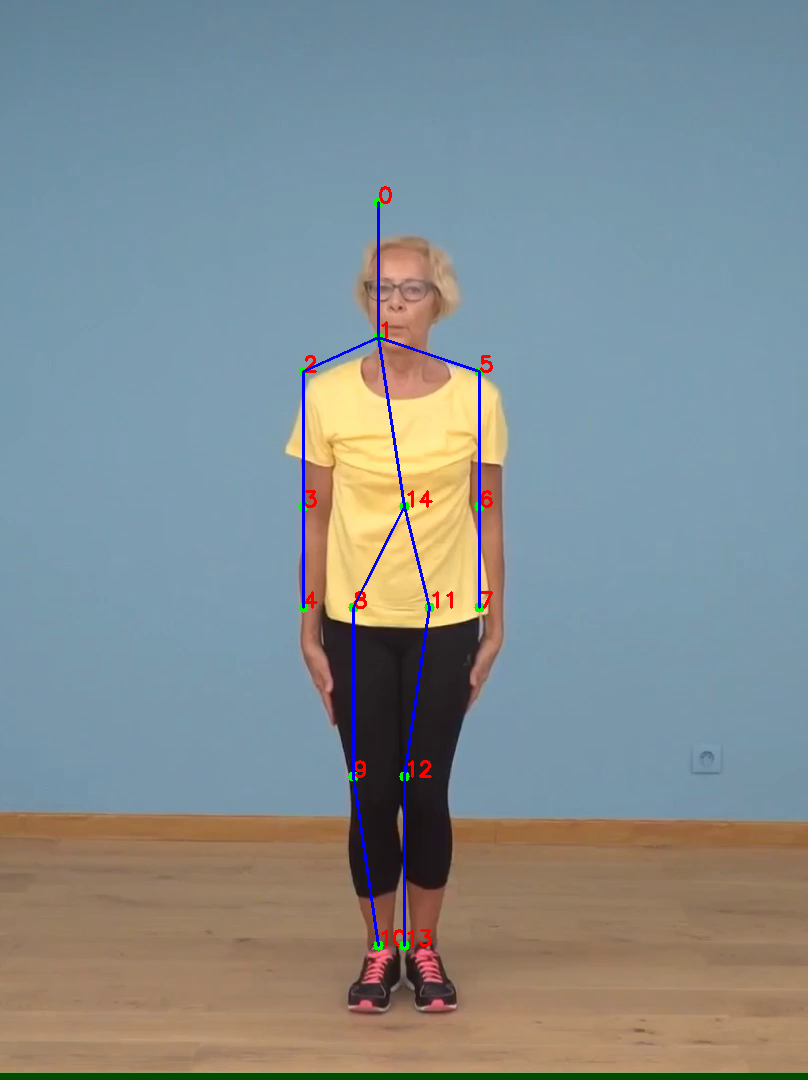


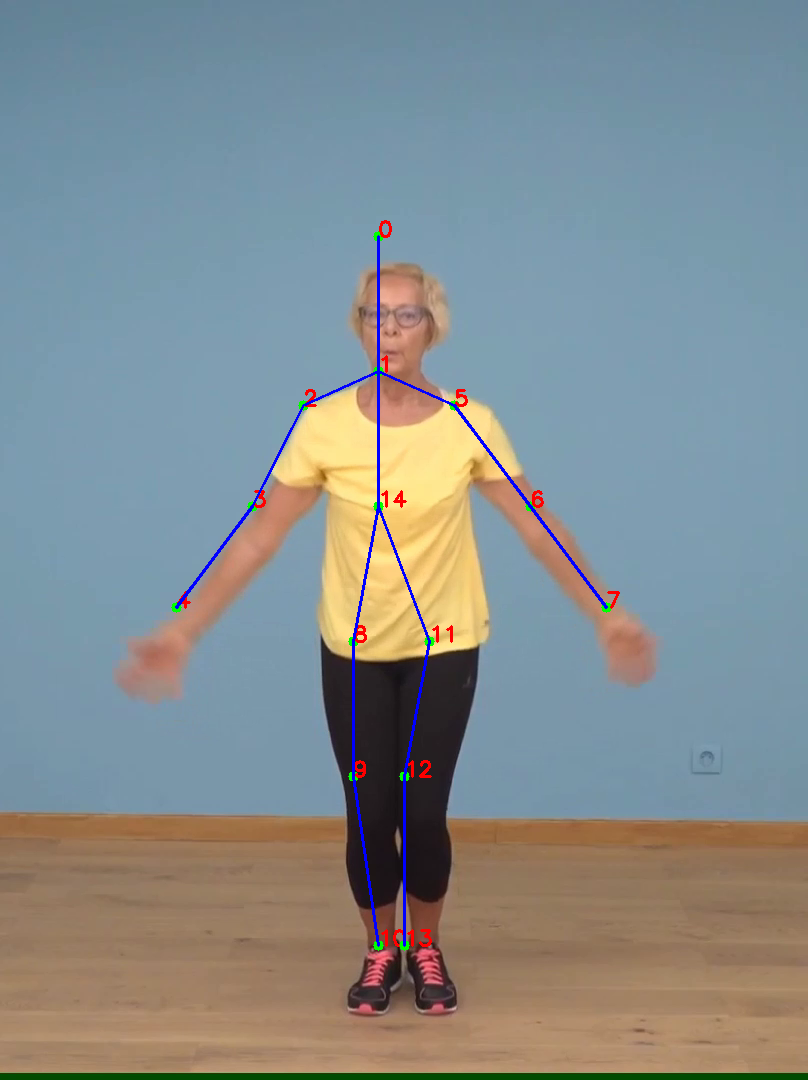


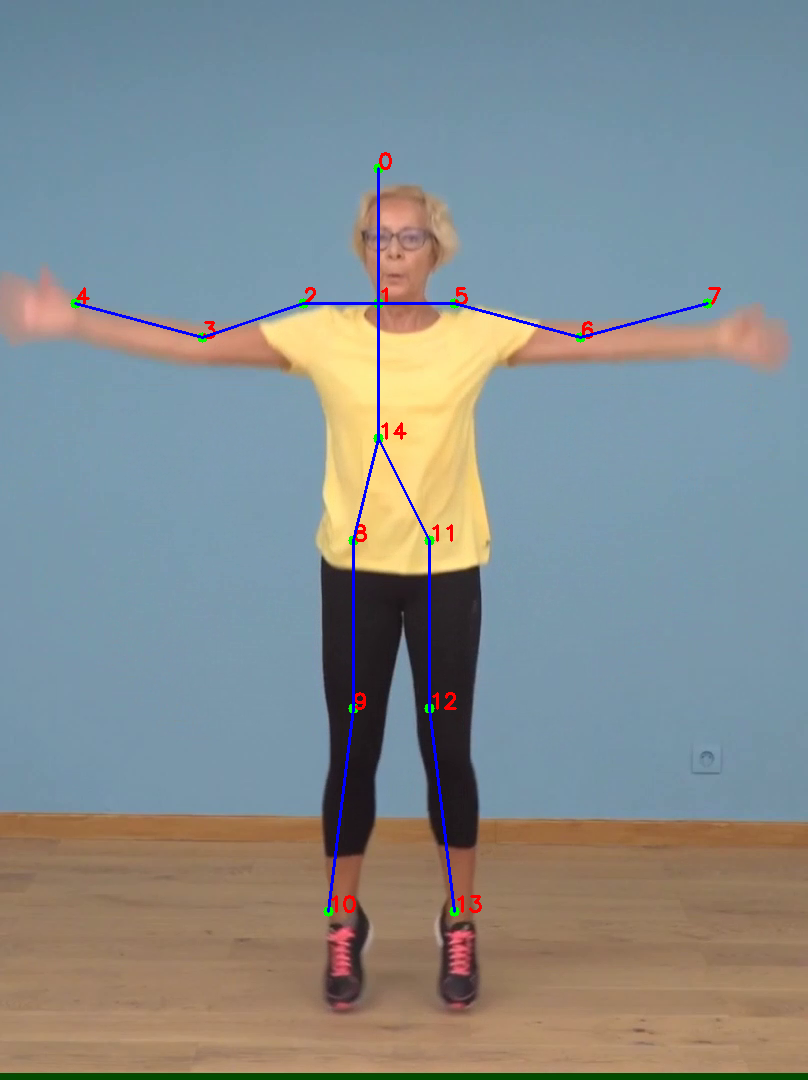


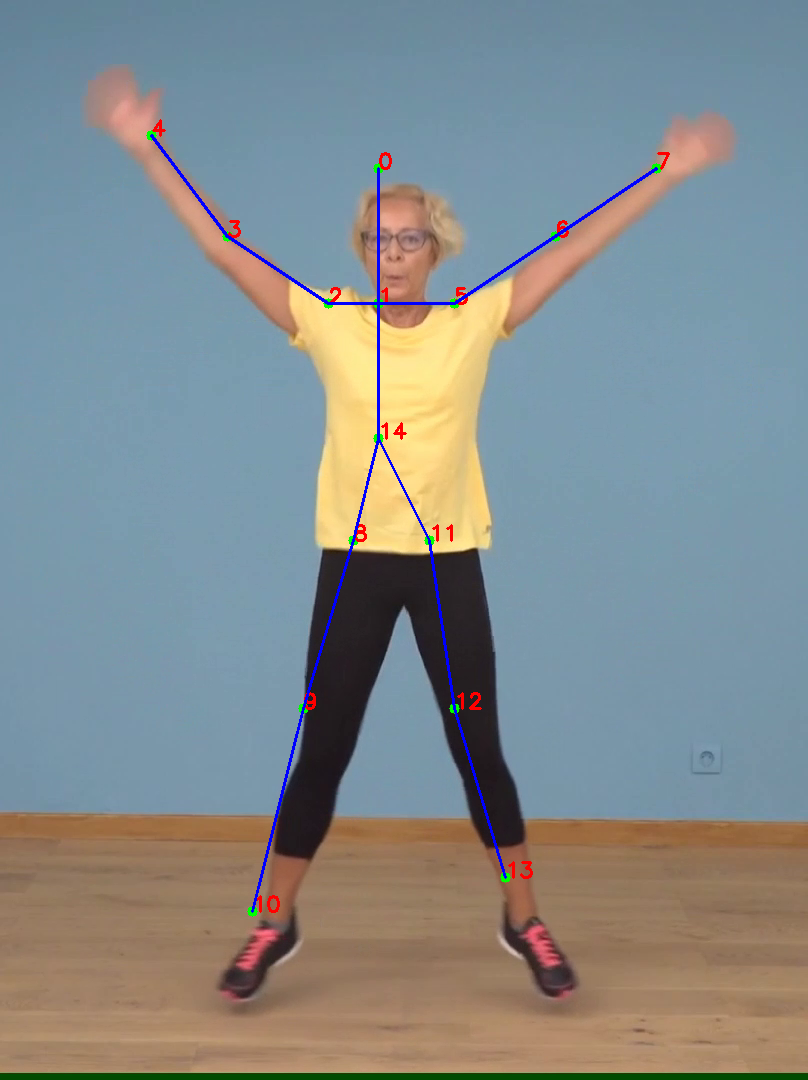


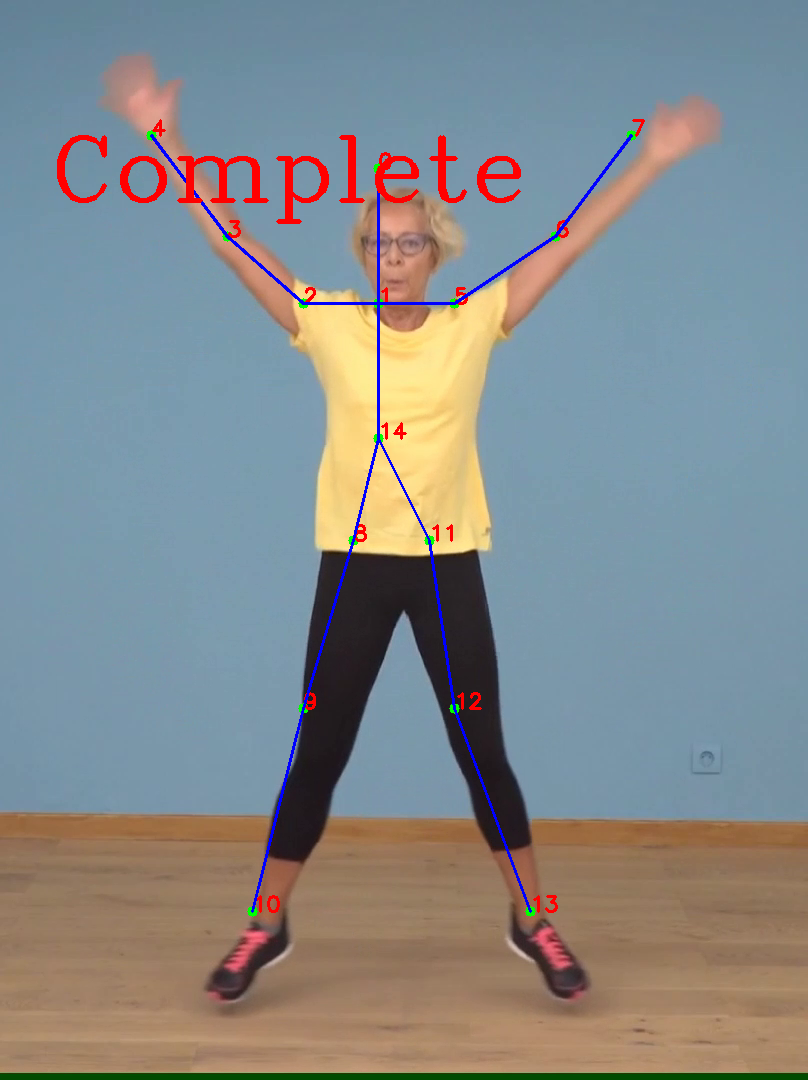


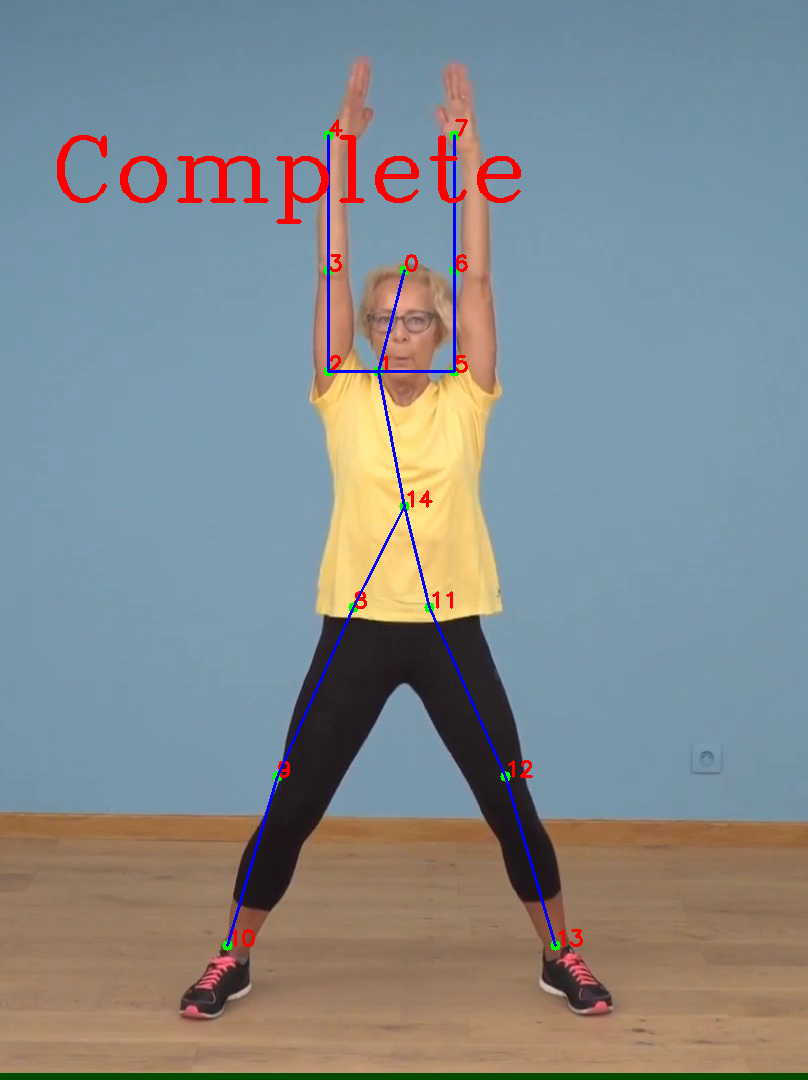
